In [4]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("../data/processed/encoded_data.csv")
model = joblib.load("../model/logistic_regression_model.pkl")
scaler = joblib.load("../model/standard_scaler.pkl")

print("Dataset Shape:", df.shape)
print("Model loaded successfully!")

Dataset Shape: (7032, 31)
Model loaded successfully!


In [7]:
X = df.drop("Churn Value", axis=1)
predictions = model.predict(X)
probabilities = model.predict_proba(X)[:,1]

In [8]:
business_df = df.copy()
business_df["Predicted_Churn"] = predictions
business_df["Churn_Probability"] = probabilities
business_df.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Predicted_Churn,Churn_Probability
0,2,53.85,108.15,1,1,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0.322054
1,2,70.70,151.65,1,0,0,0,1,1,0,...,0,0,0,0,1,0,1,0,0,0.322485
2,8,99.65,820.50,1,0,0,0,1,1,0,...,0,1,0,0,1,0,1,0,0,0.457427
3,28,104.80,3046.05,1,0,0,1,1,1,0,...,0,1,0,0,1,0,1,0,0,0.303131
4,49,103.70,5036.30,1,1,0,0,1,1,0,...,0,1,0,0,1,0,0,0,0,0.134609


In [11]:
high_risk = business_df.sort_values(by="Churn_Probability", ascending=False)
high_risk.head(10)

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Predicted_Churn,Churn_Probability
584,1,100.80,100.80,1,0,1,1,0,1,0,...,0,1,0,0,1,0,1,0,1,0.872605
886,1,95.10,95.10,1,1,1,1,0,1,0,...,0,1,0,0,1,0,1,0,1,0.872092
1582,3,94.60,279.55,1,1,1,1,0,1,0,...,0,1,0,0,1,0,1,0,1,0.866025
1382,3,95.20,292.85,1,0,0,1,0,1,0,...,0,1,0,0,1,0,1,0,1,0.862070
684,7,99.25,665.45,1,1,1,1,0,1,0,...,0,1,0,0,1,0,1,0,1,0.849623
716,1,86.05,86.05,1,1,1,1,0,1,0,...,0,0,0,0,1,0,1,0,1,0.847130
1681,7,101.95,700.85,1,1,1,1,0,1,0,...,0,1,0,0,1,0,1,0,1,0.846282
515,1,93.55,93.55,1,1,1,0,0,1,0,...,0,1,0,0,1,0,1,0,1,0.845876
373,2,93.85,170.85,1,0,1,0,0,1,0,...,0,1,0,0,1,0,1,0,1,0.845618
1255,1,94.00,94.00,1,1,1,0,0,1,0,...,0,1,0,0,1,0,1,0,1,0.845094


In [12]:
business_df["Risk_Level"] = pd.cut(
    business_df["Churn_Probability"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)

business_df["Risk_Level"].value_counts()

Risk_Level
Low       4388
Medium    1473
High      1171
Name: count, dtype: int64

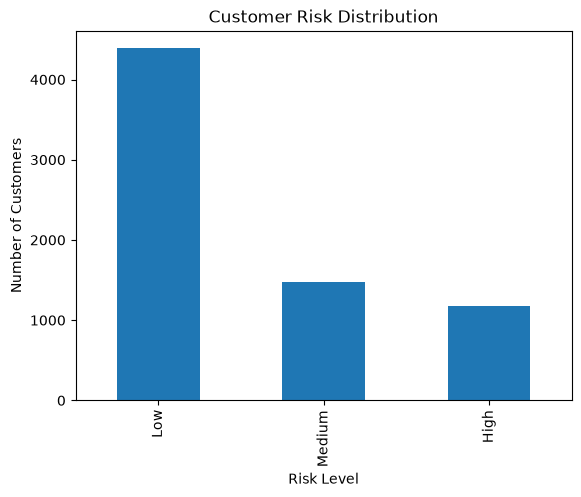

In [13]:
business_df["Risk_Level"].value_counts().plot(
    kind="bar"
)
plt.title("Customer Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.show()

In [16]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute",
    ascending=False
)

coefficients.head(15)


,Feature,Coefficient,Absolute
6,Dependents_Yes,-1.618911,1.618911
25,Contract_Two year,-1.327980,1.327980
10,Internet Service_Fiber optic,1.012578,1.012578
24,Contract_One year,-0.784459,0.784459
28,Payment Method_Electronic check,0.378454,0.378454
8,Multiple Lines_No phone service,0.375827,0.375827
21,Streaming TV_Yes,0.372333,0.372333
9,Multiple Lines_Yes,0.366953,0.366953
13,Online Security_Yes,-0.358825,0.358825
19,Tech Support_Yes,-0.344598,0.344598


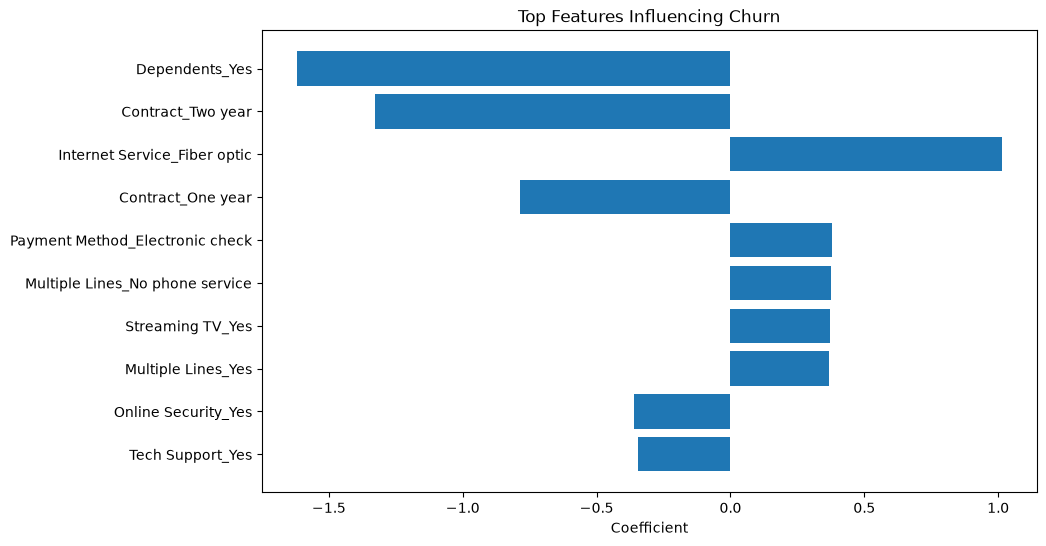

In [17]:
top = coefficients.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top["Feature"],
    top["Coefficient"]
)

plt.title("Top Features Influencing Churn")
plt.xlabel("Coefficient")
plt.gca().invert_yaxis()
plt.show()

In [18]:
business_df.to_csv("../data/processed/business_insights.csv", index=False)
print("Business insights dataset saved successfully!")

Business insights dataset saved successfully!
